CLUSTERING for STA 4724

Consider using the number of labels in the removed target variable as K in the clustering model. 

Implicitly forcing the algorithm to match the supervised structure. The goal and purpose of the algorithm
is to discover natural structure in the feature space without label guidance.

Remove target variable to find INDEPENDENT patterns in the data. Avoid leaking supervised information into unsupervised method.

In [2]:
import sys
!{sys.executable} -m pip install kagglehub

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("varishabatool/disorder")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\joaqu\.cache\kagglehub\datasets\varishabatool\disorder\versions\1


In [4]:
import kagglehub
import pandas as pd
import os
import glob

print("Dataset downloaded to:", path)

# The dataset_path is a folder; list CSVs inside
csv_files = glob.glob(os.path.join(path, "*.csv"))
print("CSV files found:", csv_files)

# Read the first CSV
df = pd.read_csv(csv_files[0])
print(df.head())

Dataset downloaded to: C:\Users\joaqu\.cache\kagglehub\datasets\varishabatool\disorder\versions\1
CSV files found: ['C:\\Users\\joaqu\\.cache\\kagglehub\\datasets\\varishabatool\\disorder\\versions\\1\\Sleep_health_and_lifestyle_dataset.csv']
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8  

#############################################################################

Dataset general information before preprocessing

##############################################################################

In [5]:
df.info()

print('\n############################################\n')

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB

#####################

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


# Notes: pretty balanced dataset. Plausible values

As first preprocessing steps.

- Remove 'Person ID' as it provides no predictive power. It works like an index.
- Fix missing values from 'Sleep Disorder' variable due to error in python interpretation.
- Fix 'Blood Pressure' variable that is listed as object. Change to float to prevent loss of information.

In [6]:
# remove index variable
df.drop(columns=['Person ID'], inplace=True)

# change NaN for No Disorder
df['Sleep Disorder'].fillna('No Disorder', inplace=True)

# fix blood pressure:
# create two new variable to preserve the nature of the original variable numerically. Then remove blood pressure
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df.drop(columns=['Blood Pressure'], inplace=True)

C:\Users\joaqu\AppData\Local\Temp\ipykernel_3228\2328399996.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sleep Disorder'].fillna('No Disorder', inplace=True)


Return the new dataframe with the new changes

In [7]:
#df.info()

print('\n############################################\n')

#df.describe()

# quick change/fix
df[['Systolic_BP', 'Diastolic_BP']] = df[['Systolic_BP', 'Diastolic_BP']].astype(int)

df.info()

print('\n############################################\n')

df.describe()



############################################

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    object 
 11  Systolic_BP              374 non-null    int64  
 12  Diastolic_BP             374 non-null    int64  
dtypes: float64(1), int64(8), object(4

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic_BP,Diastolic_BP
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920,128.553476,84.649733
std,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679,7.748118,6.161611
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000,115.000000,75.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000,125.000000,80.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000,130.000000,85.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000,135.000000,90.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000,142.000000,95.000000


Now look into Categorical Variables

**look at sublevels first before choosing the appropriate encoding.**

In [8]:
# Gender
print(df['Gender'].unique())
print(df['Gender'].nunique())

print('\n################################\n')

# Occupation
print(df['Occupation'].unique())
print(df['Occupation'].nunique())

print('\n################################\n')

# BMI Category
print(df['BMI Category'].unique())
print(df['BMI Category'].nunique())

print('\n################################\n')

# Sleep Disorder
print(df['Sleep Disorder'].unique())
print(df['Sleep Disorder'].nunique())

['Male' 'Female']
2

################################

['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']
11

################################

['Overweight' 'Normal' 'Obese' 'Normal Weight']
4

################################

['No Disorder' 'Sleep Apnea' 'Insomnia']
3


**NOTE: ['Overweight' 'Normal' 'Obese' 'Normal Weight'] : normal and normal weight are the same**


Everything looks good except for 'Occupation' which has 11 categories.

This is going to make encoding difficult for this variable.

- Gender: binary encoding

- Occupation: one-hot encoding

- Sleep Disorder: one-hot encoding

- BMI Category: nominal encoding

In [9]:
# fix BMI Category first
df['BMI Category'] = df['BMI Category'].replace({
    'Normal Weight': 'Normal'
})
print(df['BMI Category'].unique())

###############################################

# Categorial Variables Encoding

# Gender
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Occupation
df = pd.get_dummies(df, columns=['Occupation'], prefix='Occ')

# Sleep Disorder
df = pd.get_dummies(df, columns=['Sleep Disorder'], prefix='SleepDisorder')

# BMI Category
bmi_order = {
    'Normal': 0,
    'Overweight': 1,
    'Obese': 2
}

df['BMI Category'] = df['BMI Category'].map(bmi_order)



['Overweight' 'Normal' 'Obese']


In [10]:
# double check after encoding
df.select_dtypes(include=['object']).columns

Index([], dtype='object')

** Be mindful of DIMENSIONALITY **

Use PCA to address curse of dimensionality

SCALE data to avoid misleading the k means algorithm

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:
df_scaled = pd.DataFrame(X_scaled, columns=df.columns)
# Check means and standard deviations
print(df_scaled.mean().round(2))
print(df_scaled.std().round(2)) # Succesful

Gender                       0.0
Age                         -0.0
Sleep Duration               0.0
Quality of Sleep             0.0
Physical Activity Level     -0.0
Stress Level                 0.0
BMI Category                 0.0
Heart Rate                  -0.0
Daily Steps                 -0.0
Systolic_BP                 -0.0
Diastolic_BP                -0.0
Occ_Accountant               0.0
Occ_Doctor                  -0.0
Occ_Engineer                 0.0
Occ_Lawyer                  -0.0
Occ_Manager                 -0.0
Occ_Nurse                    0.0
Occ_Sales Representative     0.0
Occ_Salesperson              0.0
Occ_Scientist               -0.0
Occ_Software Engineer       -0.0
Occ_Teacher                  0.0
SleepDisorder_Insomnia      -0.0
SleepDisorder_No Disorder   -0.0
SleepDisorder_Sleep Apnea    0.0
dtype: float64
Gender                       1.0
Age                          1.0
Sleep Duration               1.0
Quality of Sleep             1.0
Physical Activity Level     

Before proceeding, briefly check for outliers as the algorithm we are about to use 
depends on euclidean distance and is heavily affected by them.

In [13]:
import numpy as np

z_scores = np.abs(df_scaled)
outlier_fraction = (z_scores > 3).sum() / len(df_scaled)
print("Fraction of data beyond 3 stds:", outlier_fraction.mean())

Fraction of data beyond 3 stds: 0.009518716577540108


In [ ]:
z_scores = np.abs((X_scaled - X_scaled.mean(axis=0)) / X_scaled.std(axis=0))
outlier_mask = (z_scores > 3).any(axis=1)
print(f"Number of outliers: {outlier_mask.sum()}")

####################################################

outliers_df = df[outlier_mask]  # look into original values
print(outliers_df) # visualize outliers


Number of outliers: 86
     Gender  Age  Sleep Duration  Quality of Sleep  Physical Activity Level  \
0         0   27             6.1                 6                       42   
3         0   28             5.9                 4                       30   
4         0   28             5.9                 4                       30   
5         0   28             5.9                 4                       30   
66        0   32             7.2                 8                       50   
..      ...  ...             ...               ...                      ...   
307       1   52             6.5                 7                       45   
308       1   52             6.6                 7                       45   
309       1   52             6.6                 7                       45   
310       1   52             6.6                 7                       45   
311       1   52             6.6                 7                       45   

     Stress Level  BMI Categ

All look like plausible values. 

Observe original dimensionality to look how well PCA does on the data

In [18]:
df.shape

(374, 25)

We finally have 25 dimensions or variables in our dataset before PCA

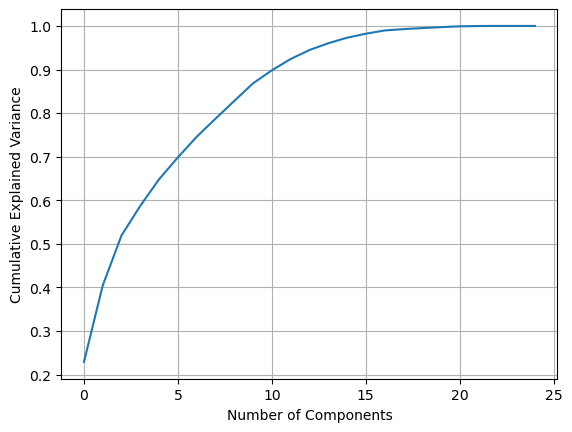

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA().fit(X_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

PCA manages to explain 90% of variance with 10 components.
The reduction from 25 to 10 dimensions is great for 
interpretability of the model.

One could argue we could use more dimensions for better results.

PROCEED

In [21]:
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance per component:", pca.explained_variance_ratio_)
print("Total explained variance:", sum(pca.explained_variance_ratio_))

Explained variance per component: [0.22911805 0.17540641 0.11486129 0.06791003 0.06105001 0.04999635
 0.04735473 0.04137926 0.04080369 0.04039648 0.02979606 0.02601213]
Total explained variance: 0.9240844940690566


A total of 12 components have a total explained variance of approximately 92.41%

Very solid results from dimension reduction

The reason we choose this number is because we managed to reduce or compress dimensions by 52% 
while retaining more than 90% of the variance.

- **Start implementing Cluster algorithm**

c:\Users\joaqu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\joaqu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\joaqu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\joaqu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

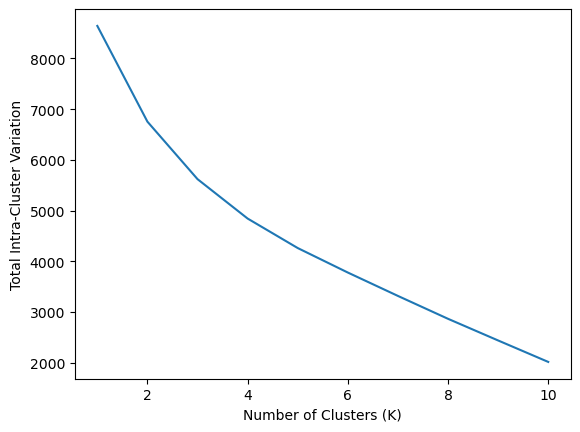

In [29]:
from sklearn.cluster import KMeans

# Record the Total Intra-Cluster Variation
ticv = [] 

for k in range(1,11): 
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=42)

    # Fit kmeans algorithm to the X dataset
    kmeans.fit(X_pca)

    # Record the Total Intra-Cluster Variation for K=k
    ticv.append(kmeans.inertia_)
    

# Plot the elbow graph
plt.plot(range(1,11),ticv)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Total Intra-Cluster Variation')
plt.show()

We will take k = 4 as the optimal number of clusters by using the elbow method.
We will also try using k = 3 later as well to compare results and verify truly what is the
best k.

c:\Users\joaqu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\joaqu\AppData\Local\Temp\ipykernel_3228\3795943931.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


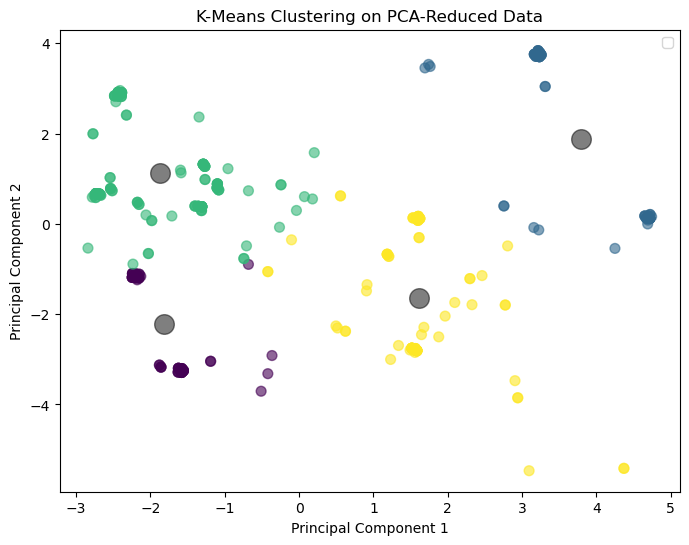

In [30]:
kmeans = KMeans(n_clusters=4, n_init=20, random_state=42)

kmeans.fit(X_pca)

# Get predicted cluster label for each point
y_kmeans = kmeans.predict(X_pca)

# Get the centers of the predicted clusters
centers = kmeans.cluster_centers_

# Plot the clustering result
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', s=50, alpha=0.6)
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.title("K-Means Clustering on PCA-Reduced Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

c:\Users\joaqu\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\joaqu\AppData\Local\Temp\ipykernel_3228\4274278536.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


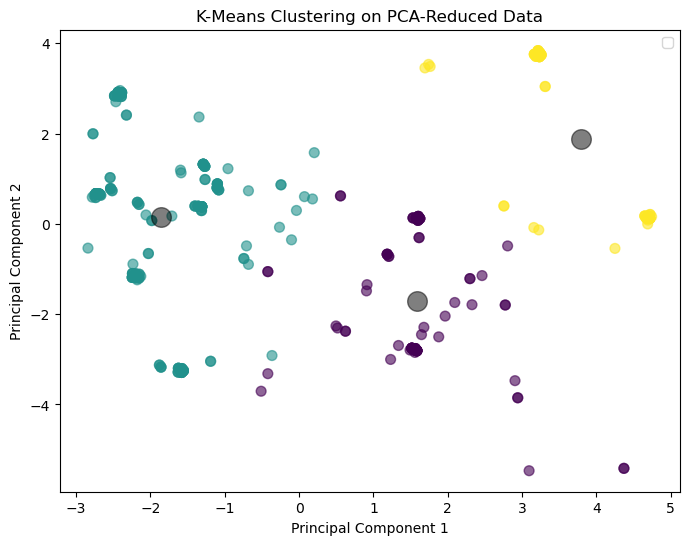

In [31]:
kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)

kmeans.fit(X_pca)

# Get predicted cluster label for each point
y_kmeans = kmeans.predict(X_pca)

# Get the centers of the predicted clusters
centers = kmeans.cluster_centers_

# Plot the clustering result
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', s=50, alpha=0.6)
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.title("K-Means Clustering on PCA-Reduced Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

**INTERPRETATION**

Colors do not overlap heavily so clusters are well separated, but most remember this is a 2D projection.

Few datapoints that are far away from clusters that may be outliers.

The separations suggest that clusters are far apart from each other in terms of the features that load into PC1

In [39]:
print("Shape of PCA components (transposed):", pca.components_.T.shape)
print("Number of numeric features:", len(df.columns))

Shape of PCA components (transposed): (25, 12)
Number of numeric features: 25


In [40]:
import numpy as np

X = df.select_dtypes(include=['float64', 'int64'])

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df.columns  # matches the 25 features
)

loadings_2D = loadings.iloc[:, :2]
print(loadings_2D)

                                PC1       PC2
Gender                     0.135301  0.269779
Age                        0.211969  0.338651
Sleep Duration            -0.166423  0.367094
Quality of Sleep          -0.147200  0.423192
Physical Activity Level    0.115326  0.166198
Stress Level               0.120588 -0.391588
BMI Category               0.357580 -0.048109
Heart Rate                 0.199393 -0.270121
Daily Steps                0.070995  0.086443
Systolic_BP                0.369282  0.087487
Diastolic_BP               0.380709  0.107149
Occ_Accountant            -0.117208  0.032632
Occ_Doctor                -0.134559 -0.219625
Occ_Engineer              -0.153041  0.188606
Occ_Lawyer                -0.064320  0.035297
Occ_Manager               -0.000927 -0.004182
Occ_Nurse                  0.300472  0.181838
Occ_Sales Representative   0.055928 -0.090555
Occ_Salesperson            0.080035 -0.190368
Occ_Scientist              0.032349 -0.073866
Occ_Software Engineer     -0.00627